In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# Path to dataset
destination = "../data/lgg-mri"

# Lists to store image and mask paths
image_paths = []
mask_paths = []

# Traverse dataset folders
for root, dirs, files in os.walk(destination):
    for file in files:
        if file.endswith(".tif") and "mask" not in file:
            image_paths.append(os.path.join(root, file))
        elif file.endswith("_mask.tif"):
            mask_paths.append(os.path.join(root, file))

# Sort to align images and masks
image_paths.sort()
mask_paths.sort()

print(f"Total images: {len(image_paths)}")
print(f"Total masks: {len(mask_paths)}")


Total images: 7858
Total masks: 7858


Tumor images: 2746
No tumor images: 5112


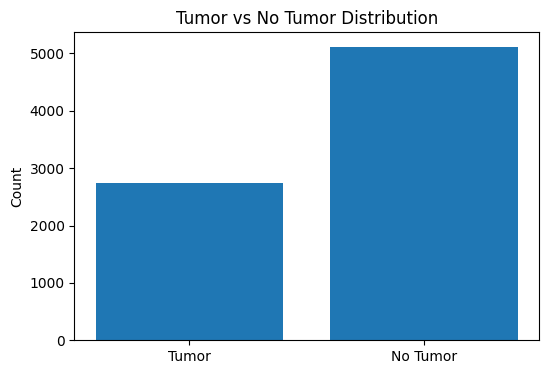

In [5]:


# -----------------------------
# 1. Count tumor vs no tumor
# -----------------------------

tumor = 0
no_tumor = 0

for mask_path in mask_paths:
    mask = cv2.imread(mask_path, 0)  # grayscale

    # If mask has any non-zero pixel → tumor
    if np.max(mask) > 0:
        tumor += 1
    else:
        no_tumor += 1

print(f"Tumor images: {tumor}")
print(f"No tumor images: {no_tumor}")

# Plot distribution
plt.figure(figsize=(6, 4))
plt.bar(["Tumor", "No Tumor"], [tumor, no_tumor])
plt.title("Tumor vs No Tumor Distribution")
plt.ylabel("Count")
plt.show()


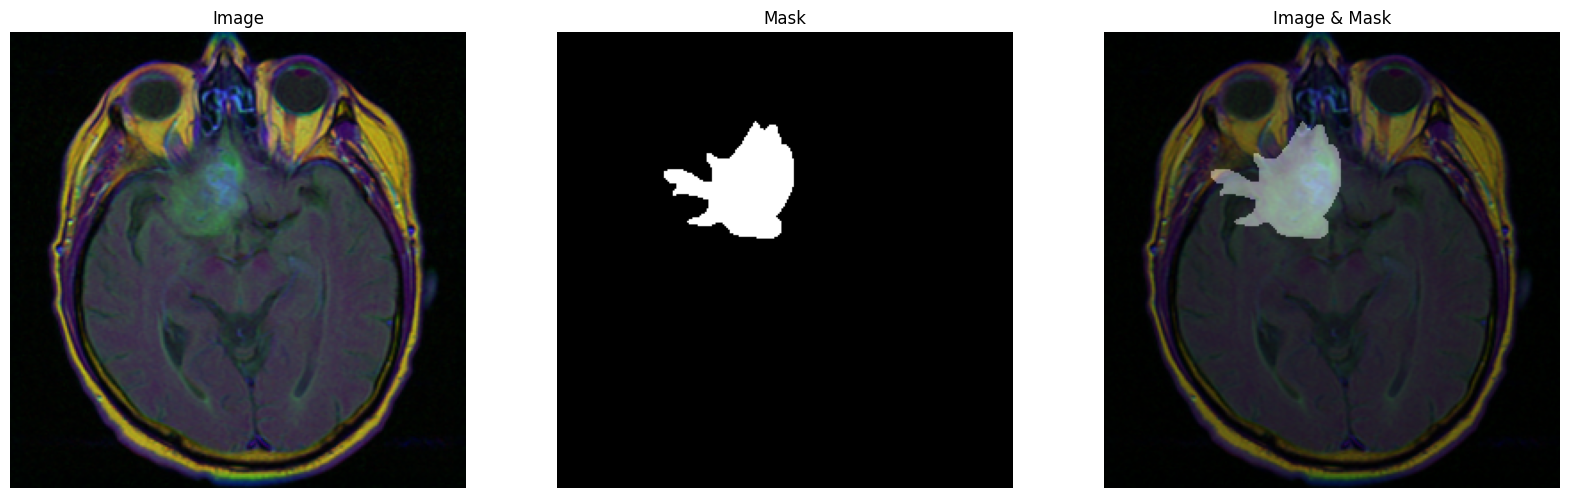

In [6]:


# -----------------------------
# 2. Show sample image + mask
# -----------------------------

index_sample = 2

image_path = image_paths[index_sample]
mask_path = mask_paths[index_sample]

image_sample = cv2.imread(image_path)
image_sample = cv2.cvtColor(image_sample, cv2.COLOR_BGR2RGB)

mask_sample = cv2.imread(mask_path)
mask_sample = cv2.cvtColor(mask_sample, cv2.COLOR_BGR2RGB)

# Plot image, mask, and overlay
fig, axs = plt.subplots(1, 3, figsize=(20, 7))

axs[0].imshow(image_sample)
axs[0].set_title("Image")
axs[0].axis("off")

axs[1].imshow(mask_sample)
axs[1].set_title("Mask")
axs[1].axis("off")

axs[2].imshow(image_sample)
axs[2].imshow(mask_sample, alpha=0.4)
axs[2].set_title("Image & Mask")
axs[2].axis("off")

plt.show()